In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/transactions_behavioral.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (283726, 39)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,Amount,Class,Hour,Time_Period,Amount_Log,Amount_Category,Transaction_Time,Transactions_Last_1H,Transactions_Last_24H,Amount_ZScore
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,149.62,0,0,Night,5.014760,Medium,0 days 00:00:00,0.0,0.0,0.244199
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,2.69,0,0,Night,1.305626,Low,0 days 00:00:00,0.0,0.0,-0.342583
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,378.66,0,0,Night,5.939276,High,0 days 00:00:01,2.0,2.0,1.158898
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,123.50,0,0,Night,4.824306,Medium,0 days 00:00:01,2.0,2.0,0.139886
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,69.99,0,0,Night,4.262539,Medium,0 days 00:00:02,4.0,4.0,-0.073813


In [2]:
df.columns.tolist()

['Time',
 'V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount',
 'Class',
 'Hour',
 'Time_Period',
 'Amount_Log',
 'Amount_Category',
 'Transaction_Time',
 'Transactions_Last_1H',
 'Transactions_Last_24H',
 'Amount_ZScore']

In [3]:
print(df["Class"].value_counts())

Class
0    283253
1       473
Name: count, dtype: int64


In [4]:
X = df.drop(columns=[
    "Class",
    "Time_Period",
    "Amount_Category",
    "Amount_ZScore",
    "Transaction_Time"  # drop non-numeric timedelta strings
])

y = df["Class"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (283726, 34)
y shape: (283726,)


In [5]:
X.dtypes

Time                     float64
V1                       float64
V2                       float64
V3                       float64
V4                       float64
V5                       float64
V6                       float64
V7                       float64
V8                       float64
V9                       float64
V10                      float64
V11                      float64
V12                      float64
V13                      float64
V14                      float64
V15                      float64
V16                      float64
V17                      float64
V18                      float64
V19                      float64
V20                      float64
V21                      float64
V22                      float64
V23                      float64
V24                      float64
V25                      float64
V26                      float64
V27                      float64
V28                      float64
Amount                   float64
Hour      

In [6]:
X.select_dtypes(include=["object", "str"]).columns

Index([], dtype='str')

In [7]:
print(X.columns.tolist())

['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Hour', 'Amount_Log', 'Transactions_Last_1H', 'Transactions_Last_24H']


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Logistic Regression

In [11]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_scaled,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [12]:
y_pred = logistic_model.predict(X_test_scaled)

print(y_pred[:20])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [13]:
y_proba = logistic_model.predict_proba(X_test_scaled)[:, 1]

print(y_proba[:20])

[2.46852745e-04 2.48136363e-04 1.50075840e-05 1.13149565e-04
 1.05771360e-03 3.20870161e-04 2.85469651e-05 7.30436301e-05
 7.94345431e-05 1.56901785e-04 1.06829477e-04 3.39505023e-04
 8.33221742e-04 2.18621952e-04 2.18463653e-04 9.24801978e-05
 3.62528581e-03 3.38665429e-05 5.04872130e-04 1.92697956e-05]


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.85      0.59      0.70        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.85     56746
weighted avg       1.00      1.00      1.00     56746



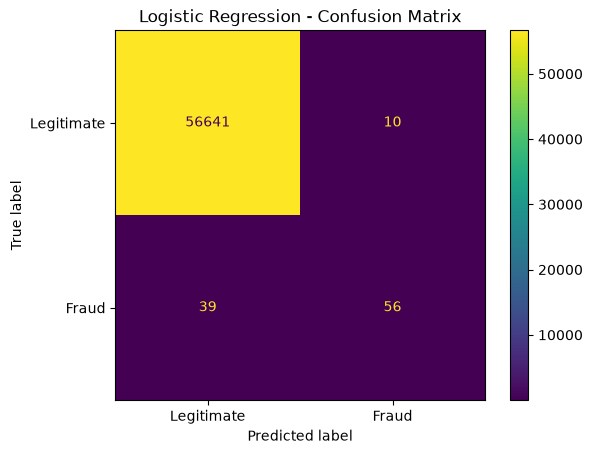

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot()

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [16]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8484848484848485
Recall: 0.5894736842105263
F1 Score: 0.6956521739130435


In [17]:
from sklearn.metrics import average_precision_score

pr_auc = average_precision_score(
    y_test,
    y_proba
)

print("PR-AUC:", pr_auc)

PR-AUC: 0.6979573556412398


In [18]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(
    y_test,
    y_proba
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9545014767240603


In [19]:
baseline_results = {
    "Model": "Logistic Regression",
    "Precision": precision,
    "Recall": recall,
    "F1 Score": f1,
    "PR-AUC": pr_auc,
    "ROC-AUC": roc_auc
}

baseline_results

{'Model': 'Logistic Regression',
 'Precision': 0.8484848484848485,
 'Recall': 0.5894736842105263,
 'F1 Score': 0.6956521739130435,
 'PR-AUC': 0.6979573556412398,
 'ROC-AUC': 0.9545014767240603}

In [20]:
results_df = pd.DataFrame([baseline_results])

results_df

,Model,Precision,Recall,F1 Score,PR-AUC,ROC-AUC
0,Logistic Regression,0.848485,0.589474,0.695652,0.697957,0.954501


In [21]:
import joblib

joblib.dump(
    logistic_model,
    "../models/logistic_baseline.pkl"
)

joblib.dump(
    scaler,
    "../models/scaler.pkl"
)

['../models/scaler.pkl']